# Graph API

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

In [2]:
hf_token=os.getenv("HF_TOKEN")

In [5]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image, display


In [16]:
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint

llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    task="conversational",
    huggingfacehub_api_token=hf_token,
    max_new_tokens=200,
    temperature=0.7
)

chat_llm = ChatHuggingFace(llm=llm)

In [17]:
!pip install -U langchain-huggingface

Defaulting to user installation because normal site-packages is not writeable


In [105]:
#graph state

class State(TypedDict):
    topic:str
    joke:str
    improved_joke:str
    final_joke:str

In [106]:
#nodes

def generate_joke(state:State):
    """First LLM call to generate joke"""
    msg=chat_llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke":msg.content}

def check_punchline(state:State):
    """gate  function to check if the joke has punchline"""

    #simple check-soes the joke contain ? or !
    if '?' in state['joke'] or '!'in state['joke']:
        return "Pass"
    return "Fail"

In [107]:
def improve_joke(state:State):
    """Second LLM call to improve the joke"""

    msg=chat_llm.invoke(f"Make this joke funnier by adding wordplay : {state['joke']}")

    return {"improved_joke":msg.content}

In [108]:
def polish_joke(state:State):
    """Third LLM call for final polish"""

    msg=chat_llm.invoke(f"Add a surprising twist to this joke : {state['improved_joke']}")
    return {"final_joke":msg.content}

In [109]:
# build workflow

workflow=StateGraph(State)

#add nodes
workflow.add_node("generate_joke",generate_joke)
workflow.add_node("improve_joke",improve_joke)
workflow.add_node("polish_joke",polish_joke)

In [110]:
# add edges to connect nodes

workflow.add_edge(START,"generate_joke")
workflow.add_conditional_edges(
    "generate_joke",check_punchline,{"Fail":"improve_joke", "Pass":END}
)

workflow.add_edge("improve_joke","polish_joke")

workflow.add_edge("polish_joke",END)

In [111]:
#compile

chain=workflow.compile()



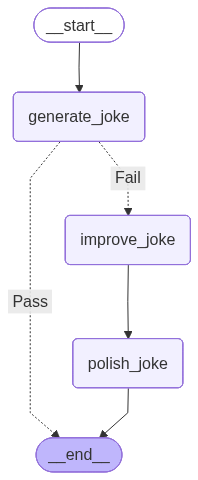

In [112]:
# show workflow

display(Image(chain.get_graph().draw_mermaid_png()))

In [113]:
#invoke

state=chain.invoke({"topic":"cats"})

In [114]:
print("Initial Joke:")
print(state['joke'])

Initial Joke:
Why did the cat join the book club?

Because she wanted to purrivate her opinions!


In [116]:
if 'joke' in state:
    print("Initial Joke:")
    print(state['joke'])

if 'improved_joke' in state:
    print("\nImproved Joke:")
    print(state['improved_joke'])

if 'final_joke' in state:
    print("\nFinal Joke:")
    print(state['final_joke'])

Initial Joke:
Why did the cat join the book club?

Because she wanted to purrivate her opinions!


# Functional API

In [4]:
from langgraph.func import entrypoint,task

In [18]:
#tasks 

@task
def generate_joke(topic:str):
    """Fisrt LLM call to generate initial joke"""
    msg=chat_llm.invoke(f"Write a short joke about topic{topic}")
    return msg.content

In [22]:
def check_punchline(joke:str):
    """Gate func to check if the joke has a punchline"""
    #simple check -does joke have ? or !
    if "?" in joke or "!" in joke:
        return "Fail"
    return "Pass"

@task
def improve_joke(joke:str):
    """Second LLM call to improve joke"""
    msg=chat_llm.invoke(f"make this joke funnier by adding wordplay :{joke}")
    return msg.content

@task
def polish_joke(joke:str):
    """Third LLM call for final polish"""
    msg=chat_llm.invoke(f"Add a surprising twist to this joke:{joke}")
    return msg.content

@entrypoint()
def prompt_chaining_workflow(topic:str):
    original_joke=generate_joke(topic).result()
    if check_punchline(original_joke)=="Pass":
        return original_joke

    improved_joke=improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()



In [23]:
# Invoke

stream=prompt_chaining_workflow.stream_events("cats",version="v3")

In [24]:
for snapshot in stream.values:
    print(snapshot)
    print("\n")

[{'type': 'text', 'text': "Why did the topiccat refuse to jump into the pond?\n\nBecause it didn't want to engage in a cold, fishy discussion!", 'index': 0}]


